In [46]:
import joblib 

In [47]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
dfs = pd.read_csv("../data/features.csv", index_col="Time_[s]")
targets = pd.read_csv("../data/targets.csv", index_col=False)
# df = dfs[dfs["Experiment_ID"]==2].drop(columns=["Experiment_ID"])
# target = targets[targets["Experiment_ID"]==2].iloc[:, 2:]
col = "Angle[degree]ORDistance[mm]"

scaler = MinMaxScaler(feature_range=(0, 1))
targets[col] = scaler.fit_transform(targets[[col]])
targets

,Unnamed: 0,Experiment_ID,Angle[degree]ORDistance[mm],Secondary-axis [mm],Main-axis [mm],Out-of-roundness [-],Collapse [mm]
0,0,2,0.000000,0.317461,0.337050,0.626034,0.344543
1,1,2,0.022036,0.319825,0.363018,0.600159,0.372211
2,2,2,0.044072,0.319035,0.401244,0.560835,0.412939
3,3,2,0.066108,0.317768,0.438220,0.522651,0.452336
4,4,2,0.088145,0.320230,0.465094,0.495879,0.480970
...,...,...,...,...,...,...,...
4616,14374,314,0.903482,0.602647,0.400094,0.641878,0.341981
4617,14375,314,0.925518,0.618405,0.398324,0.648210,0.340095
4618,14376,314,0.947554,0.631936,0.397945,0.652486,0.339691
4619,14377,314,0.969590,0.640013,0.399376,0.653355,0.341216


In [48]:
groups_y = []
max_len_y = targets.groupby("Experiment_ID").size().max()
num_target_features = targets.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in targets.groupby("Experiment_ID"):
    values = group.drop(columns=["Experiment_ID"]).values  # (len_group, num_target_features)
    
    # Pad with NaN
    padded = np.full((max_len_y, num_target_features), np.nan)
    padded[:values.shape[0], :] = values
    groups_y.append(padded)

# Final y: (num_experiments, max_len, num_target_features)
y = np.array(groups_y, dtype=float)

# Replace NaN with 0
Y = np.nan_to_num(y, nan=0.0)



groups = []
max_len = dfs.groupby("Experiment_ID").size().max()  # longest experiment
num_features = dfs.shape[1] - 1  # exclude Experiment_ID

for exp_id, group in dfs.groupby("Experiment_ID"):
    features = group.drop(columns=["Experiment_ID"]).values
    
    # Pad with NaN (or zeros) to match max_len
    padded = np.full((max_len, num_features), np.nan)  
    padded[:features.shape[0], :] = features
    groups.append(padded)


X = np.array(groups, dtype=float)
X = np.nan_to_num(X, nan=0.0)[:10,:,:]
Y = np.nan_to_num(y, nan=0.0)[:10,:,2:]
print("Shape:", X.shape, Y.shape)  

Shape: (10, 1743, 17) (10, 47, 4)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import numpy as np

# Convert your data to PyTorch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test (e.g., 80% train, 20% test)
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Seq2Vec LSTM Model
class Seq2VecLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, num_angles):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size * num_angles)
        self.num_angles = num_angles
        self.output_size = output_size

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        hn = hn[-1]
        out = self.fc(hn)
        out = out.view(-1, self.num_angles, self.output_size)
        return out

input_size = X.shape[2]
hidden_size = 128
num_layers = 3
output_size = Y.shape[2]
num_angles = Y.shape[1]

model = Seq2VecLSTM(input_size, hidden_size, num_layers, output_size, num_angles)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Early stopping parameters
patience = 10
best_loss = float('inf')
counter = 0

# Training loop with early stopping
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    
    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred = model(xb)
            loss = criterion(y_pred, yb)
            test_loss += loss.item() * xb.size(0)
    test_loss /= len(test_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.6f}, Test Loss: {test_loss:.6f}")

    # Early stopping check
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
# Save model 
joblib.dump(model, "lstm.pkl")
# Load the best model for evaluation
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).numpy()


Epoch [1/200], Train Loss: 0.168499, Test Loss: 0.154412
Epoch [2/200], Train Loss: 0.167821, Test Loss: 0.153773
Epoch [3/200], Train Loss: 0.167143, Test Loss: 0.153133
Epoch [4/200], Train Loss: 0.166464, Test Loss: 0.152491
Epoch [5/200], Train Loss: 0.165783, Test Loss: 0.151847
Epoch [6/200], Train Loss: 0.165099, Test Loss: 0.151199
Epoch [7/200], Train Loss: 0.164411, Test Loss: 0.150546
Epoch [8/200], Train Loss: 0.163718, Test Loss: 0.149888
Epoch [9/200], Train Loss: 0.163018, Test Loss: 0.149222
Epoch [10/200], Train Loss: 0.162311, Test Loss: 0.148548
Epoch [11/200], Train Loss: 0.161595, Test Loss: 0.147865
Epoch [12/200], Train Loss: 0.160868, Test Loss: 0.147170
Epoch [13/200], Train Loss: 0.160129, Test Loss: 0.146463
Epoch [14/200], Train Loss: 0.159376, Test Loss: 0.145741
Epoch [15/200], Train Loss: 0.158608, Test Loss: 0.145003
Epoch [16/200], Train Loss: 0.157822, Test Loss: 0.144247
Epoch [17/200], Train Loss: 0.157017, Test Loss: 0.143470
Epoch [18/200], Train L

In [50]:
model = joblib.load("lstm.pkl")

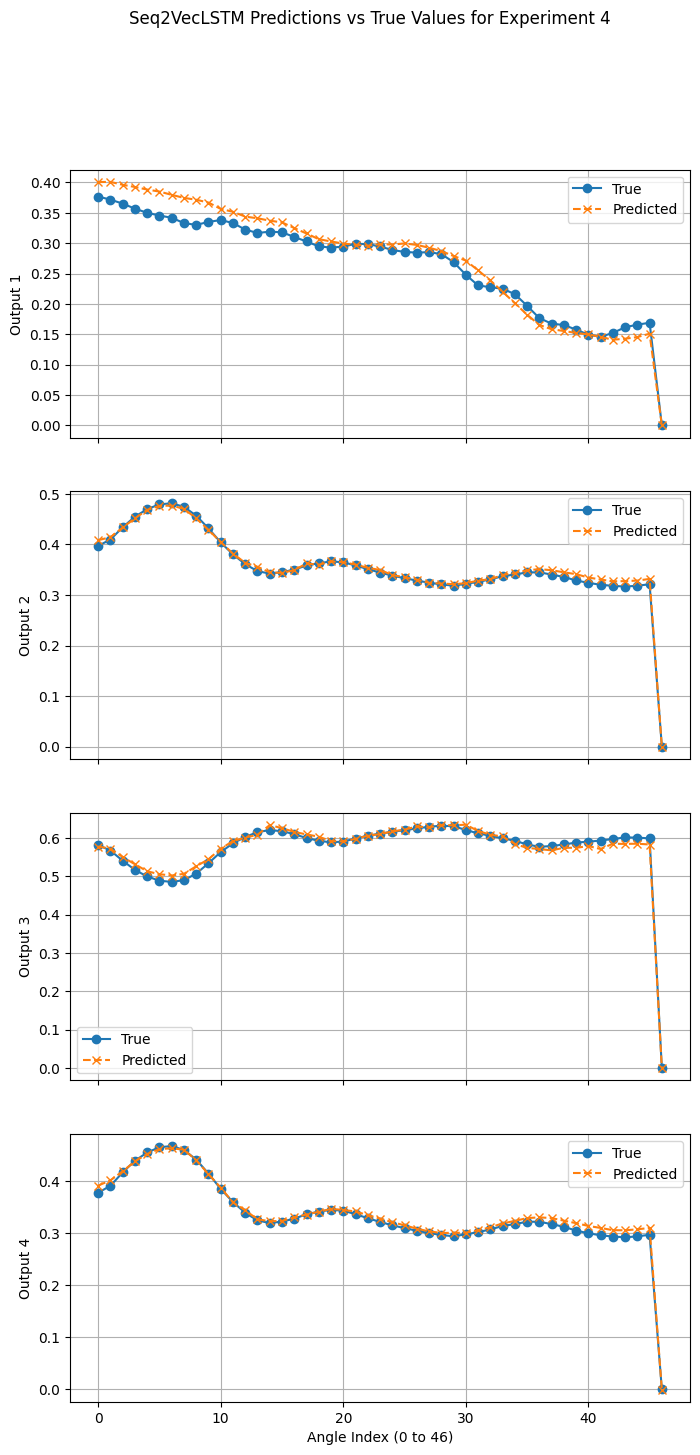

Experiment 4 - MSE: 0.000150, RMSE: 0.012264, MAE: 0.008743


In [80]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import torch

# Make predictions
model.eval()
with torch.no_grad():
    Y_pred = model(X_tensor).detach().cpu().numpy()  # shape: (num_samples, num_angles, num_outputs)

num_outputs = Y_pred.shape[2]

# Select an experiment to visualize
experiment_idx = 4

true_vals = Y_tensor[experiment_idx].cpu().numpy()  # shape: (num_angles, num_outputs)
pred_vals = Y_pred[experiment_idx]                  # shape: (num_angles, num_outputs)

# Plot predictions vs true values
fig, axs = plt.subplots(num_outputs, 1, figsize=(8, 4*num_outputs), sharex=True)
axs = np.atleast_1d(axs)  # ensure axs is array-like even if num_outputs=1

output_names = [f"Output {i+1}" for i in range(num_outputs)]

for i in range(num_outputs):
    axs[i].plot(true_vals[:, i], label="True", marker='o')
    axs[i].plot(pred_vals[:, i], label="Predicted", marker='x', linestyle='--')
    axs[i].set_ylabel(output_names[i])
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel("Angle Index (0 to 46)")
plt.suptitle(f"Seq2VecLSTM Predictions vs True Values for Experiment {experiment_idx}")
plt.show()

# Compute evaluation metrics
mse = mean_squared_error(true_vals, pred_vals)
mae = mean_absolute_error(true_vals, pred_vals)
rmse = np.sqrt(mse)

print(f"Experiment {experiment_idx} - MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")


In [ ]:
def plot_most_accurate_window_lstm(sample_idx, X, Y, model, num_angles, num_features, patch_size, angle_idx=0):
    import matplotlib.pyplot as plt
    import numpy as np
    import torch

    model.eval()  # make sure model is in eval mode
    
    _, seq_len, _ = X.shape
    num_patches = seq_len // patch_size
    
    x_input = X[sample_idx].copy()  # shape: (seq_len, num_features)
    y_true = Y[sample_idx, angle_idx]  # shape: (num_outputs,) or scalar
    y_true = np.array(y_true)

    # ---------- Evaluate error for each patch ----------
    window_errors = []
    for w in range(num_patches):
        x_patch_only = np.zeros_like(x_input)  # mask all other patches
        start = w * patch_size
        end = (w + 1) * patch_size
        x_patch_only[start:end, :] = x_input[start:end, :]  # keep only this patch
        
        # Make prediction
        x_tensor = torch.tensor(x_patch_only[np.newaxis, :, :], dtype=torch.float32)
        with torch.no_grad():
            y_hat = model(x_tensor).cpu().numpy()[0, angle_idx]
        
        if y_true.ndim == 0:
            error = abs(y_true - y_hat)
        else:
            error = np.linalg.norm(y_true - y_hat)
        window_errors.append(error)
    
    window_errors = np.array(window_errors)
    most_accurate_window = np.argmin(window_errors)
    
    # ---------- Plot features + highlight most accurate ----------
    plt.figure(figsize=(12, 6))
    for f in range(num_features):
        plt.plot(x_input[:, f], label=f'Feature {f}')
    
    plt.axvspan(most_accurate_window*patch_size,
                (most_accurate_window+1)*patch_size-1,
                color='green', alpha=0.3, label='Most Accurate Window')
    
    # Overlay error curve for each patch
    error_curve = np.repeat(window_errors, patch_size)
    ax2 = plt.gca().twinx()
    ax2.plot(range(len(error_curve)), error_curve, color='black', linestyle='--',
             linewidth=2, label='Prediction Error per Patch')
    ax2.set_ylabel("Error (L2 norm if vector)")
    
    plt.xlabel("Timestep")
    plt.title(f"Sample {sample_idx}, Angle {angle_idx} - Most Accurate Window & Error Curve")
    plt.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()
    
    # ---------- Predictions for all angles ----------
    x_tensor = torch.tensor(x_input[np.newaxis, :, :], dtype=torch.float32)
    with torch.no_grad():
        preds = model(x_tensor).cpu().numpy()[0]  # shape: (num_angles, num_outputs)
    
    # ---------- Plot true vs predicted ----------
    plt.figure(figsize=(12, 6))
    for out_idx in range(Y.shape[2]):
        plt.plot(range(num_angles), Y[sample_idx, :, out_idx], label=f'True Output {out_idx}')
        plt.plot(range(num_angles), preds[:, out_idx], label=f'Predicted Output {out_idx}', linestyle='--', marker='x')
    plt.xlabel("Angle index")
    plt.ylabel("Target value(s)")
    plt.title(f"Predictions for Sample {sample_idx} across all angles")
    plt.legend()
    plt.grid(True)
    plt.show()


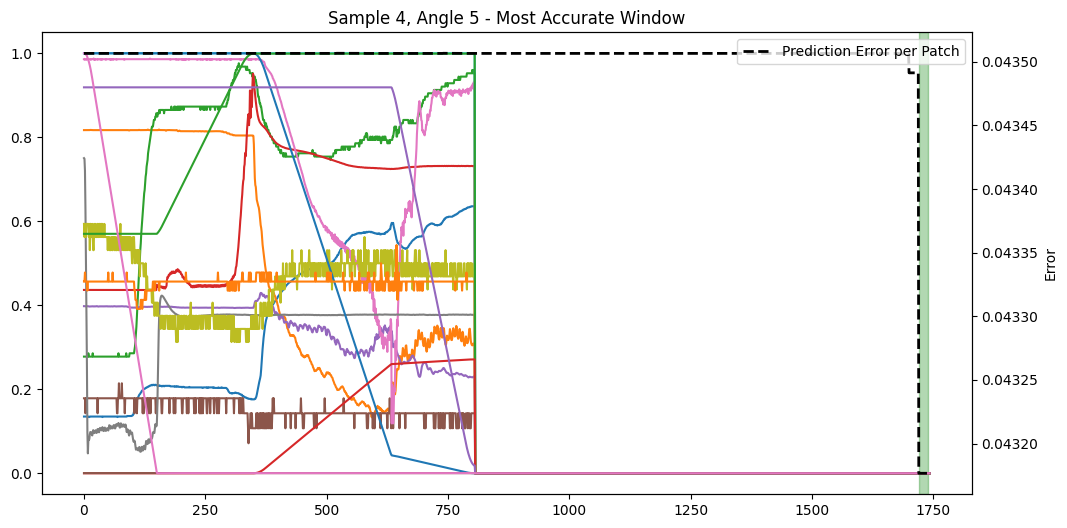

In [99]:
# Parameters
sample_idx = 4
angle_idx = 5
num_angles = Y.shape[1]      # 47
num_features = X.shape[2]    # number of input features per timestep
patch_size = 20               # you can adjust this based on your sequence length

# Call the function
plot_most_accurate_window_lstm(sample_idx, X, Y, model, num_angles, num_features, patch_size, angle_idx)

In [ ]:
input_size = X.shape[2]
hidden_size = 128
num_layers = 2
output_size = Y.shape[2]
num_angles = Y.shape[1]

Epoch [1/50] Train Loss: 0.198544, Test Loss: 0.201457
Epoch [2/50] Train Loss: 0.190701, Test Loss: 0.192749
Epoch [3/50] Train Loss: 0.182226, Test Loss: 0.182199
Epoch [4/50] Train Loss: 0.171975, Test Loss: 0.168435
Epoch [5/50] Train Loss: 0.158638, Test Loss: 0.149754
Epoch [6/50] Train Loss: 0.140605, Test Loss: 0.124251
Epoch [7/50] Train Loss: 0.116137, Test Loss: 0.091713
Epoch [8/50] Train Loss: 0.085308, Test Loss: 0.060704
Epoch [9/50] Train Loss: 0.057074, Test Loss: 0.054078
Epoch [10/50] Train Loss: 0.054022, Test Loss: 0.051355
Epoch [11/50] Train Loss: 0.052884, Test Loss: 0.038288
Epoch [12/50] Train Loss: 0.039948, Test Loss: 0.023819
Epoch [13/50] Train Loss: 0.024890, Test Loss: 0.014078
Epoch [14/50] Train Loss: 0.014283, Test Loss: 0.009899
Epoch [15/50] Train Loss: 0.009267, Test Loss: 0.009048
Epoch [16/50] Train Loss: 0.007778, Test Loss: 0.009105
Epoch [17/50] Train Loss: 0.007459, Test Loss: 0.008820
Epoch [18/50] Train Loss: 0.007043, Test Loss: 0.008037
E

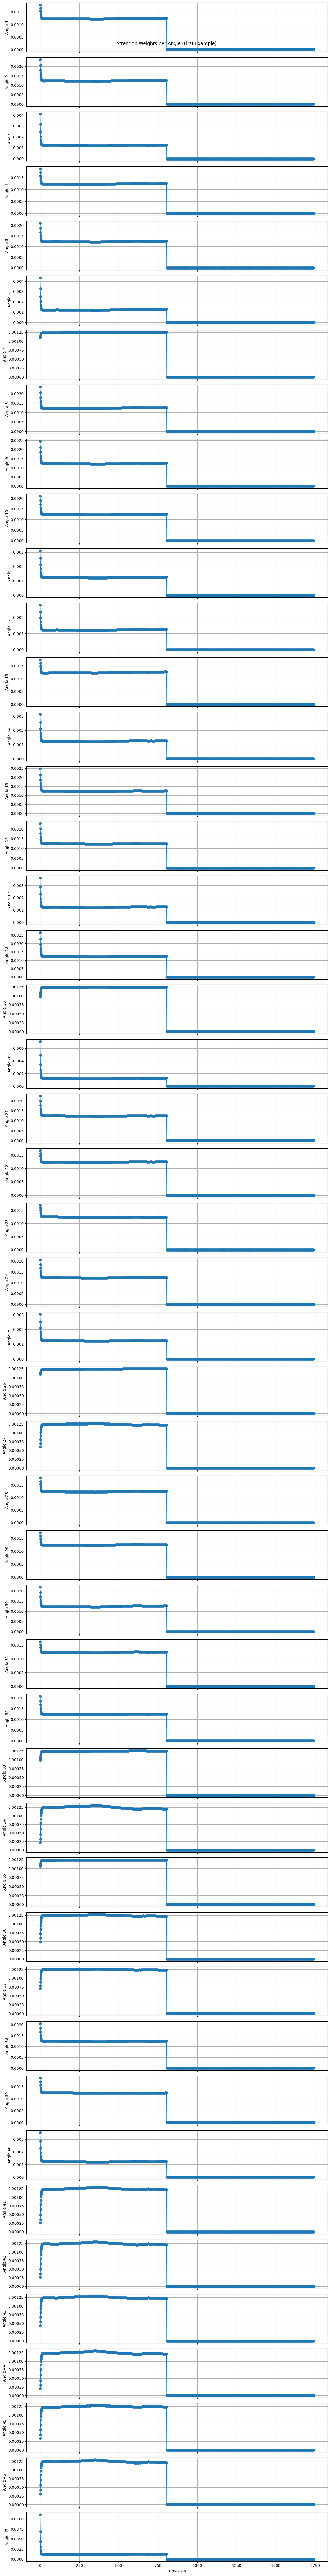

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# Convert your data to PyTorch tensors
# ----------------------------
X_tensor = torch.tensor(X, dtype=torch.float32)  # (num_samples, seq_len, num_features)
Y_tensor = torch.tensor(Y, dtype=torch.float32)  # (num_samples, num_angles, 3)

# Split dataset into train and test
dataset = TensorDataset(X_tensor, Y_tensor)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# ----------------------------
# Model definition with monotonic cumulative attention
# ----------------------------
class MLPAttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_angles, output_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.attn_layers = nn.ModuleList([nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        ) for _ in range(num_angles)])
        self.fc_layers = nn.ModuleList([nn.Linear(hidden_size, output_size) for _ in range(num_angles)])

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)  # (batch, seq_len, hidden_size)
        outputs, all_attn_scores = [], []

        # ---- Create mask for zero-timesteps ----
        # True if the whole feature vector at this timestep is zero
        zero_mask = torch.all(x == 0, dim=-1)   # (batch, seq_len)

        for i in range(len(self.fc_layers)):
            attn_scores = self.attn_layers[i](lstm_out).squeeze(-1)  # (batch, seq_len)

            # set attention logits to -inf where input is zero → softmax = 0
            attn_scores = attn_scores.masked_fill(zero_mask, float("-inf"))

            attn_weights = F.softmax(attn_scores, dim=1)             # (batch, seq_len)

            # replace NaNs if all timesteps were -inf (avoid crash)
            attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

            # context vector
            context = torch.sum(lstm_out * attn_weights.unsqueeze(-1), dim=1)  # (batch, hidden_size)

            outputs.append(self.fc_layers[i](context).unsqueeze(1))
            all_attn_scores.append(attn_weights.unsqueeze(1))

        out = torch.cat(outputs, dim=1)               # (batch, num_angles, output_size)
        all_attn_scores = torch.cat(all_attn_scores, dim=1)  # (batch, num_angles, seq_len)
        return out, all_attn_scores


# ----------------------------
# Training setup
# ----------------------------
input_size = X.shape[2]
hidden_size = 128
num_layers = 2
output_size = Y.shape[2]
num_angles = Y.shape[1]
num_epochs = 50

model = MLPAttentionLSTM(input_size, hidden_size, num_layers, num_angles, output_size)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

# ----------------------------
# Training loop
# ----------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred, attn_weights = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # Evaluate on test set
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            y_pred, _ = model(xb)
            loss = criterion(y_pred, yb)
            test_loss += loss.item() * xb.size(0)
    test_loss /= len(test_loader.dataset)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.6f}, Test Loss: {test_loss:.6f}")

# ----------------------------
# Debug visualization: Attention weights for one example
# ----------------------------
model.eval()
with torch.no_grad():
    Y_pred, attn_weights = model(X_tensor[:1])  # take first sample
attn_weights = attn_weights[0].cpu().numpy()  # (num_angles, seq_len)

num_angles, seq_len = attn_weights.shape
fig, axs = plt.subplots(num_angles, 1, figsize=(12, 2*num_angles), sharex=True)

for i in range(num_angles):
    axs[i].plot(range(seq_len), attn_weights[i], marker='o')
    axs[i].set_ylabel(f"Angle {i+1}")
    axs[i].grid(True)

axs[-1].set_xlabel("Timestep")
plt.suptitle("Attention Weights per Angle (First Example)")
plt.tight_layout()
plt.show()


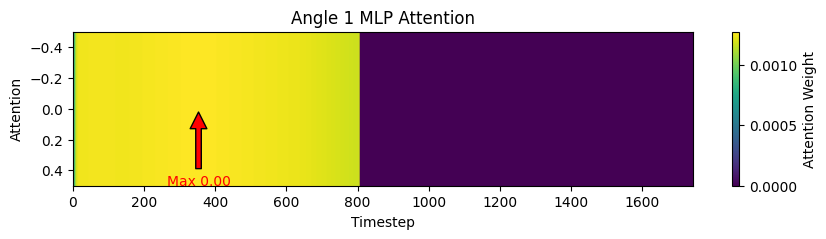

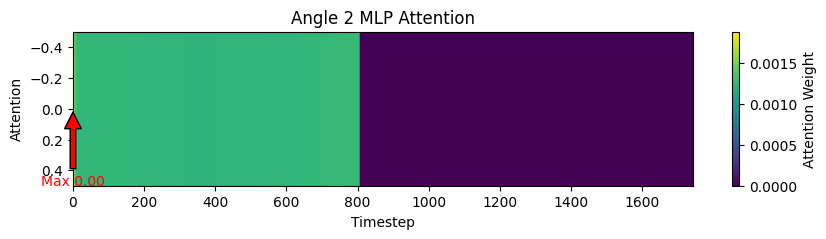

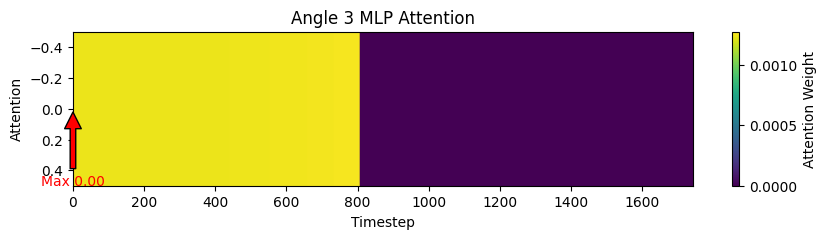

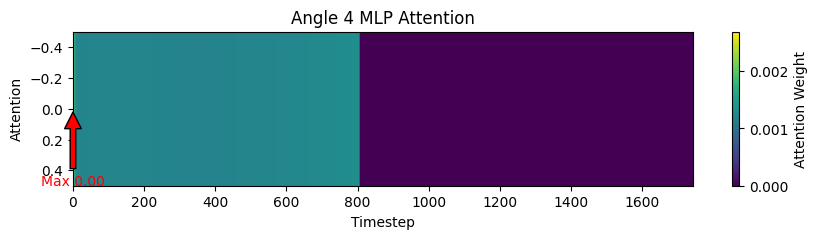

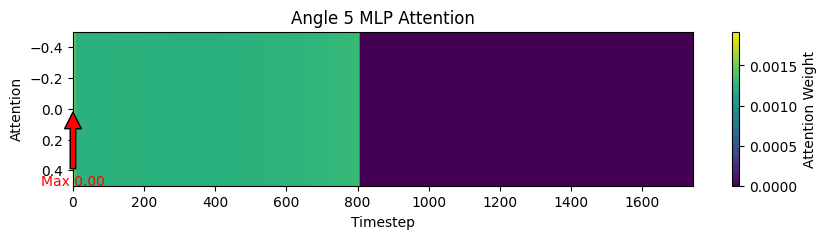

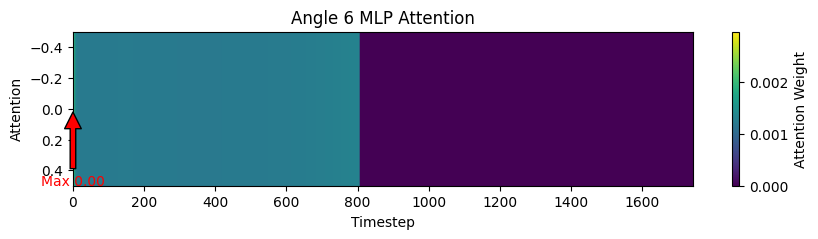

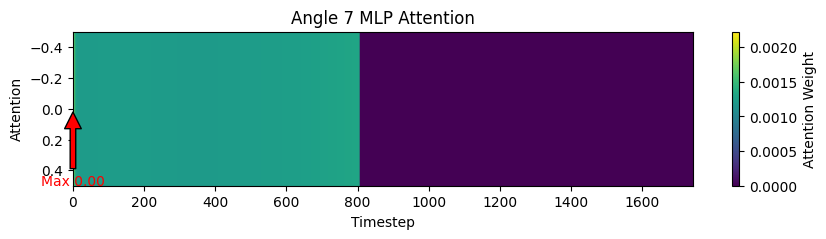

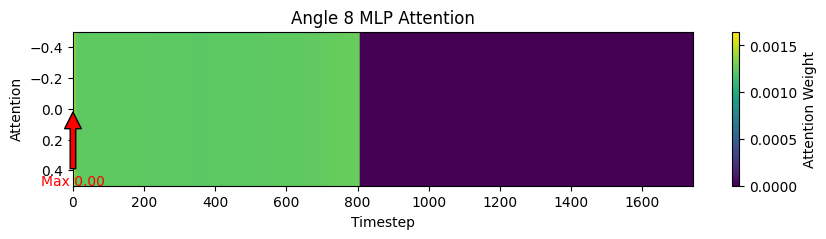

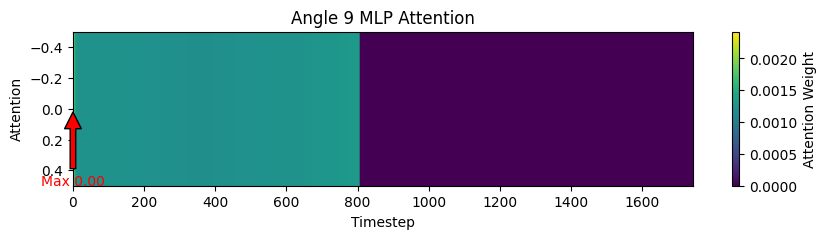

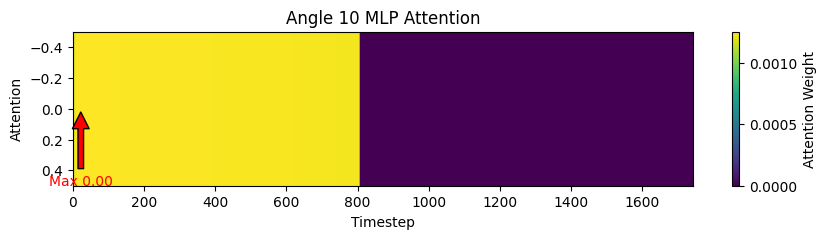

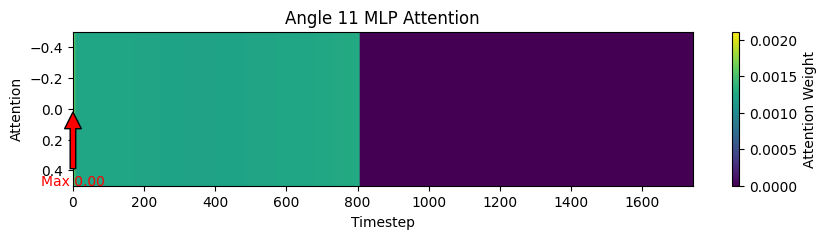

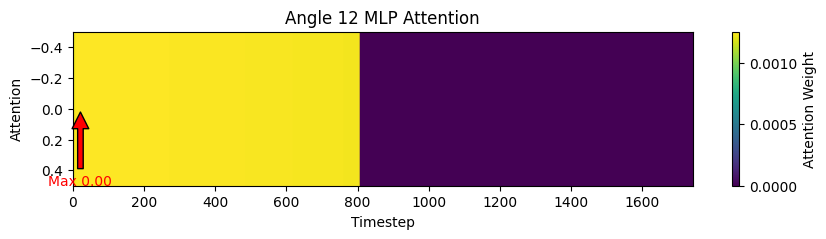

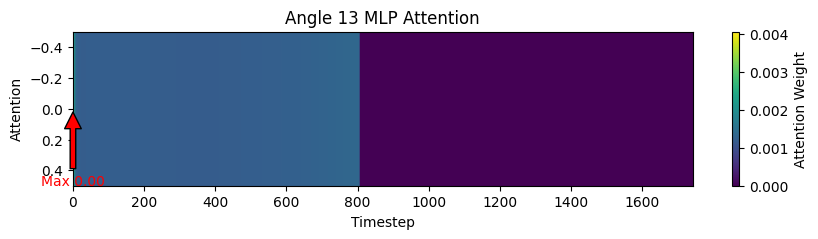

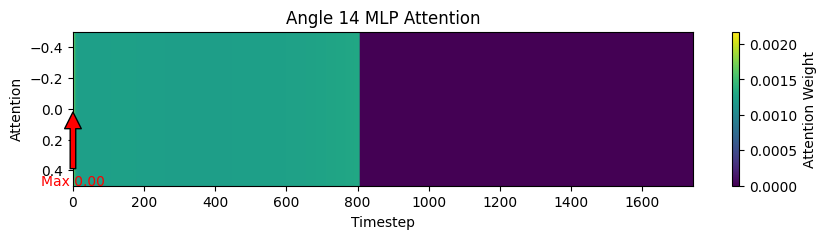

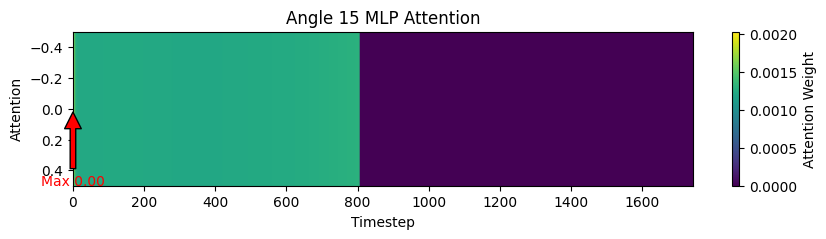

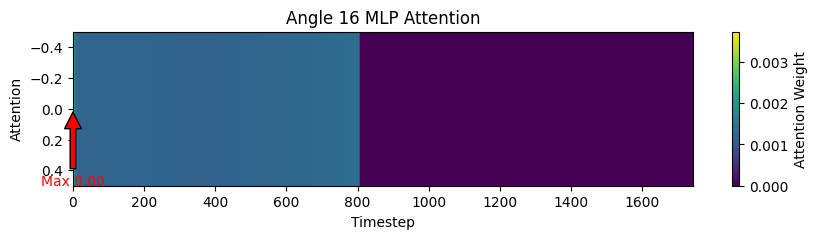

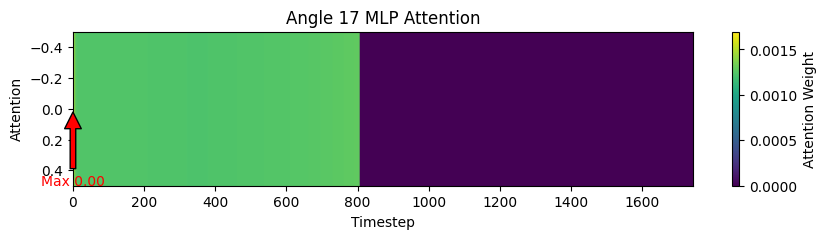

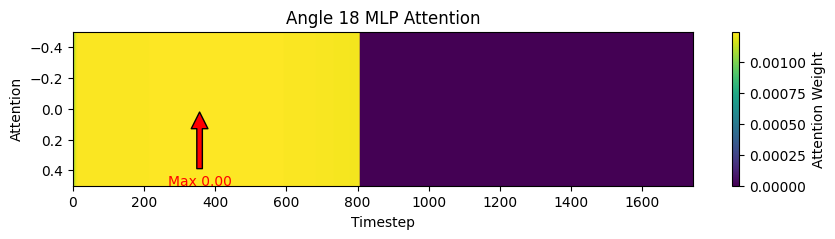

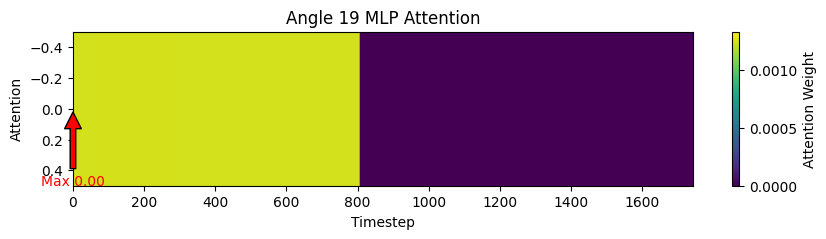

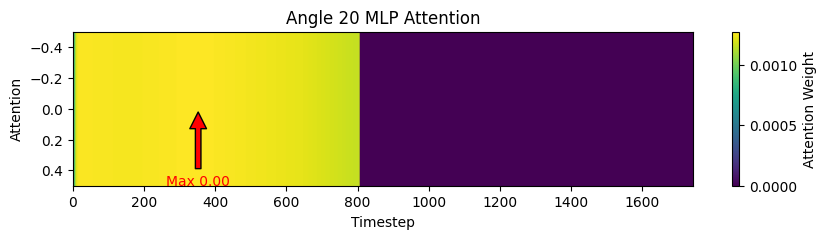

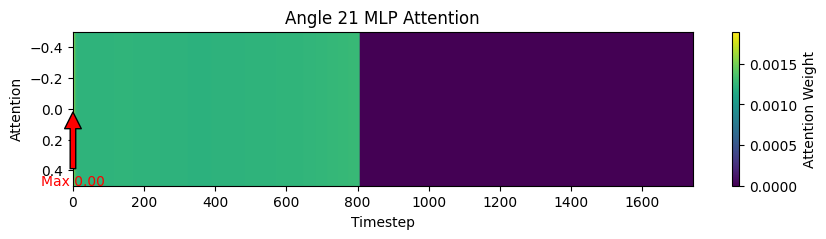

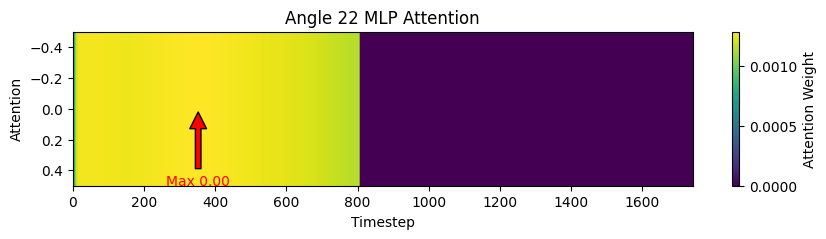

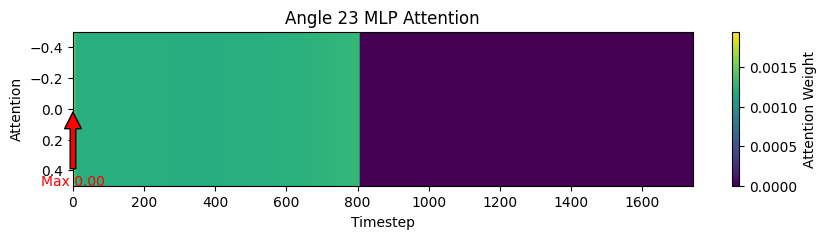

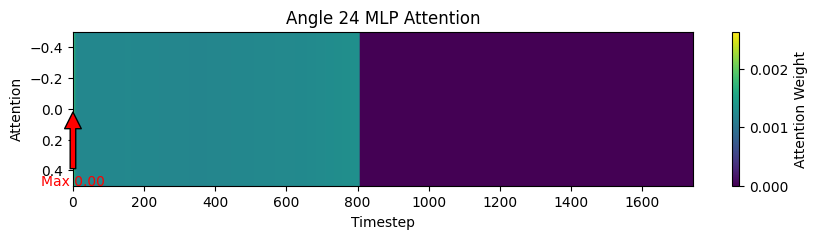

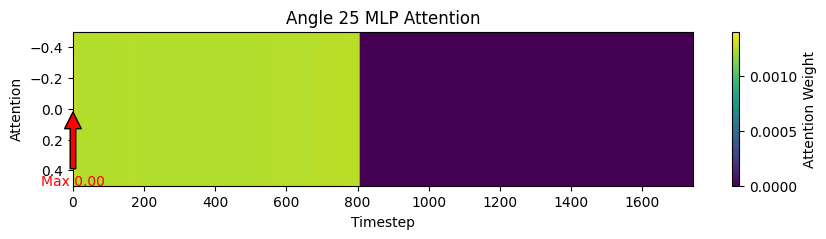

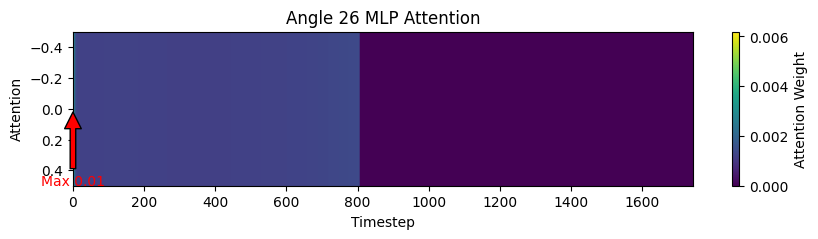

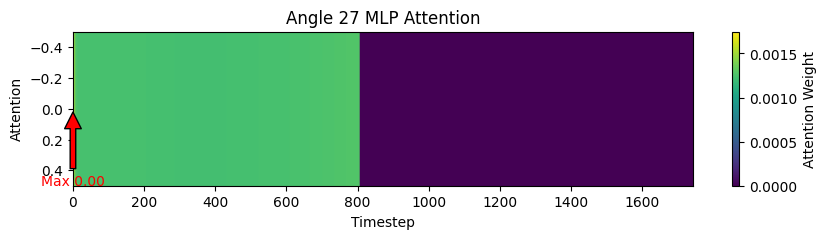

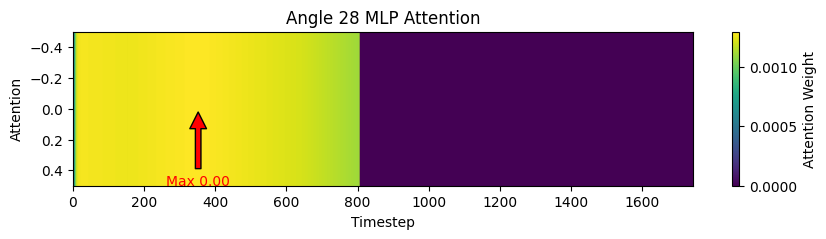

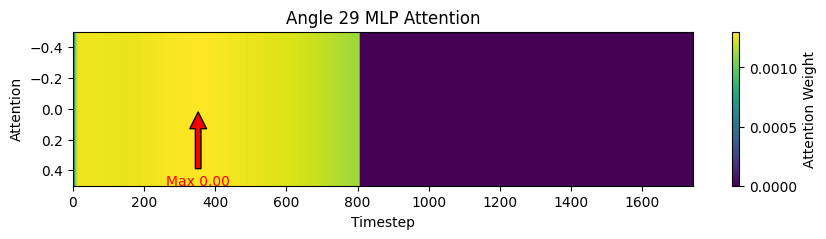

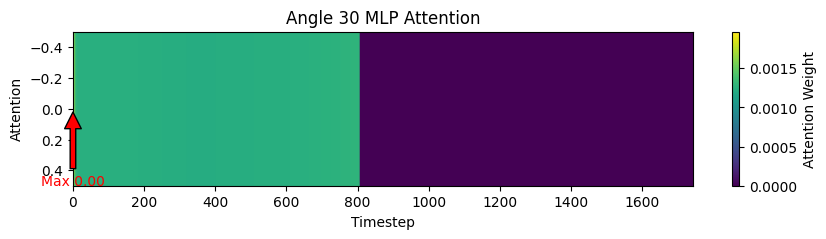

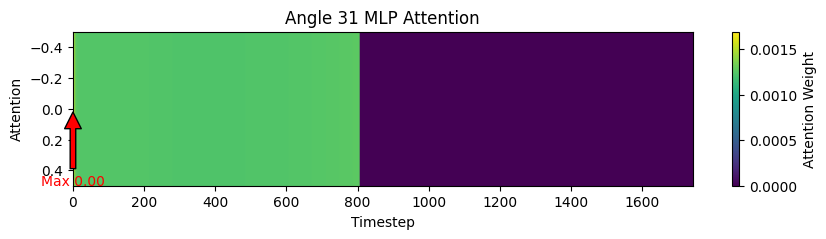

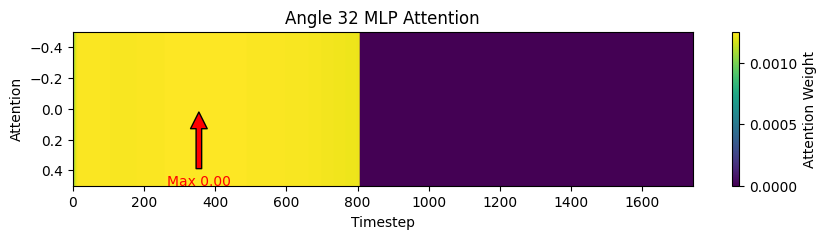

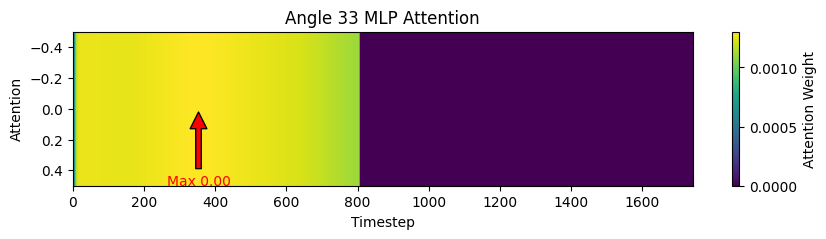

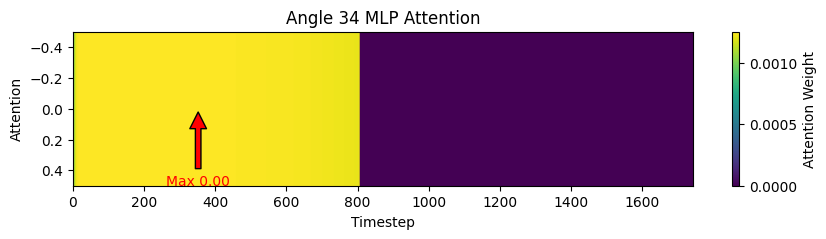

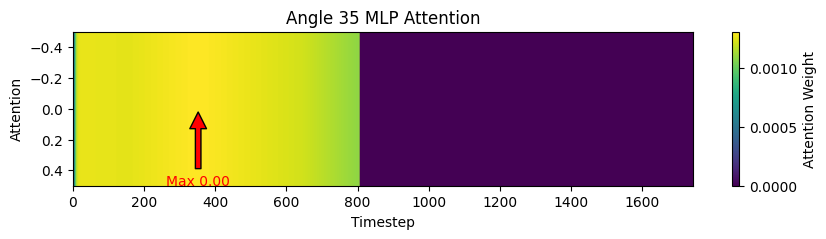

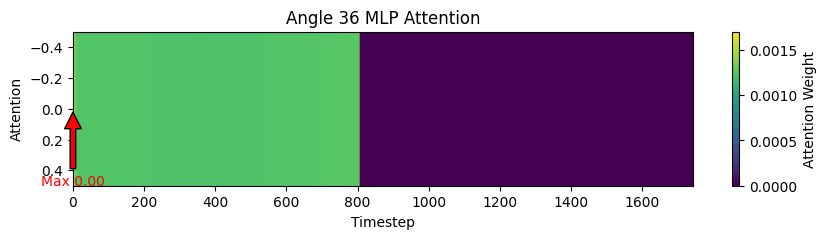

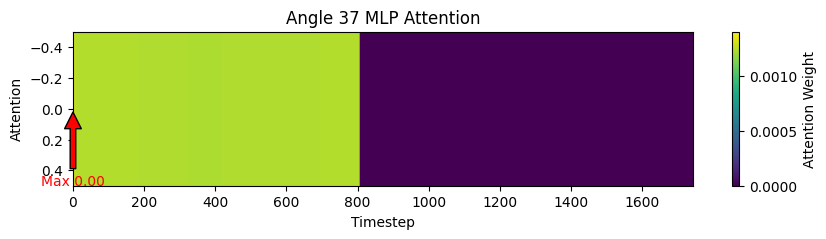

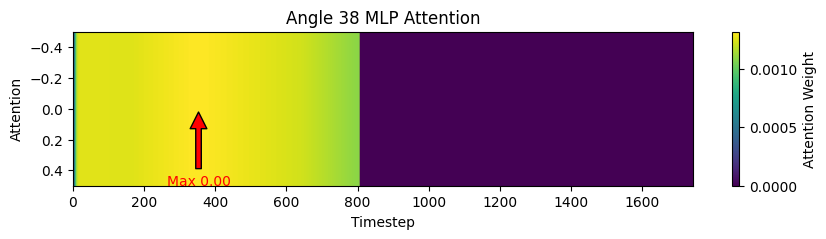

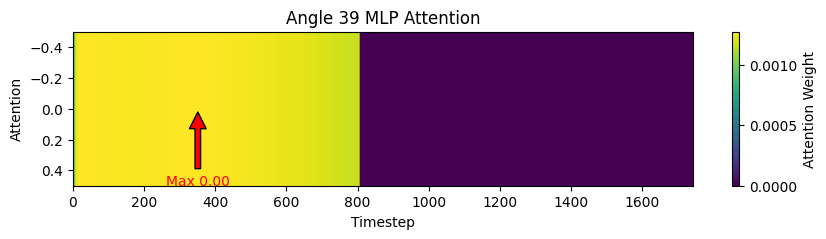

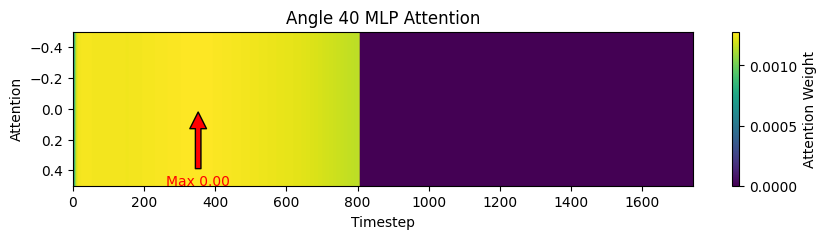

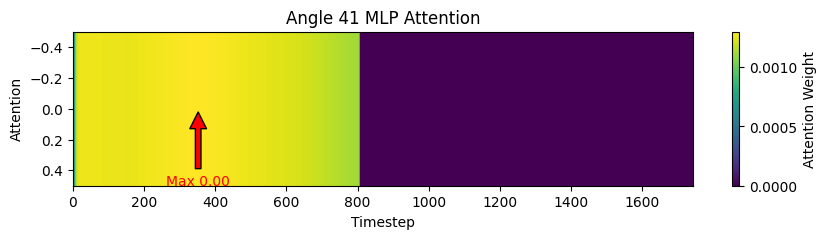

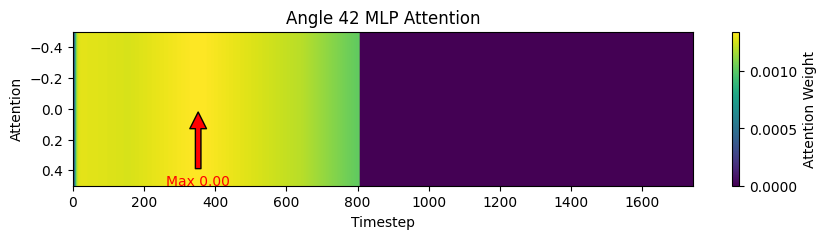

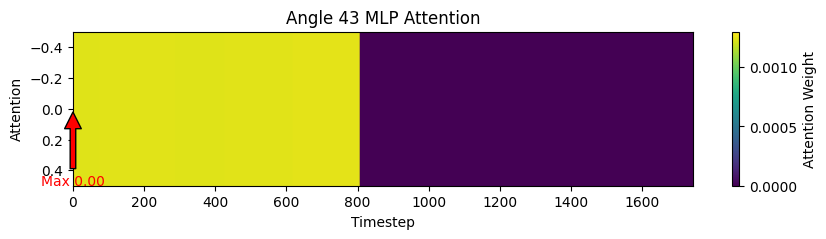

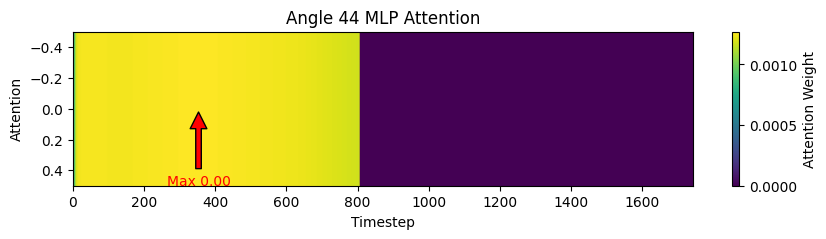

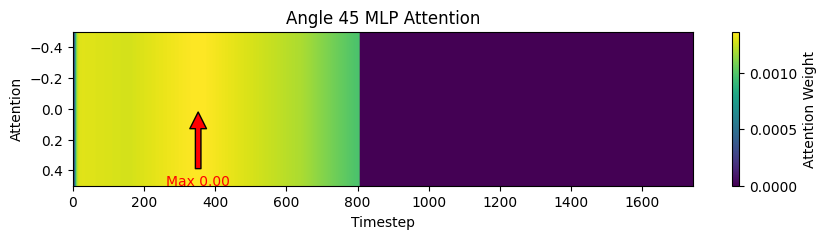

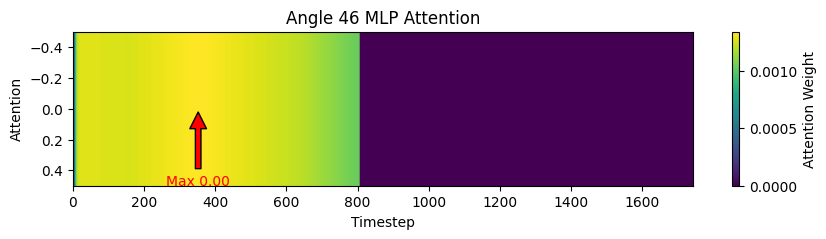

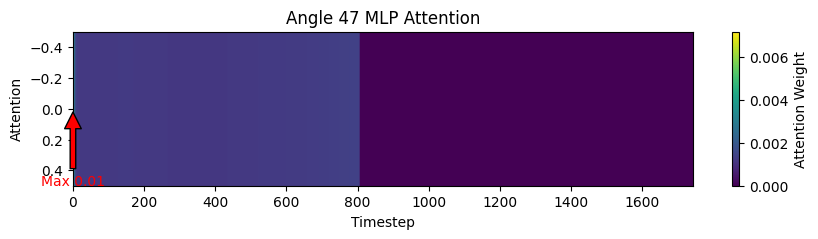

In [15]:
model.eval()
with torch.no_grad():
    X_tensor_eval = torch.tensor(X, dtype=torch.float32)  # ensure it's a tensor
    Y_pred, attn = model(X_tensor_eval)
    attn = attn.numpy()

for angle_idx in range(num_angles):
    plt.figure(figsize=(10, 2))
    attn_vec = attn[0, angle_idx]   # shape: (timesteps,)

    # Find highest point
    max_idx = np.argmax(attn_vec)
    max_val = attn_vec[max_idx]

    # Plot heatmap
    plt.imshow(attn_vec.reshape(1, -1), cmap='viridis', aspect='auto')
    plt.colorbar(label='Attention Weight')
    plt.title(f'Angle {angle_idx+1} MLP Attention')
    plt.xlabel('Timestep')
    plt.ylabel('Attention')

    # Add red annotation (arrow + text)
    plt.annotate(f"Max {max_val:.2f}",
                 xy=(max_idx, 0), xycoords='data',
                 xytext=(max_idx, 0.5), textcoords='data',
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 ha='center', color='red', fontsize=10)

    plt.show()


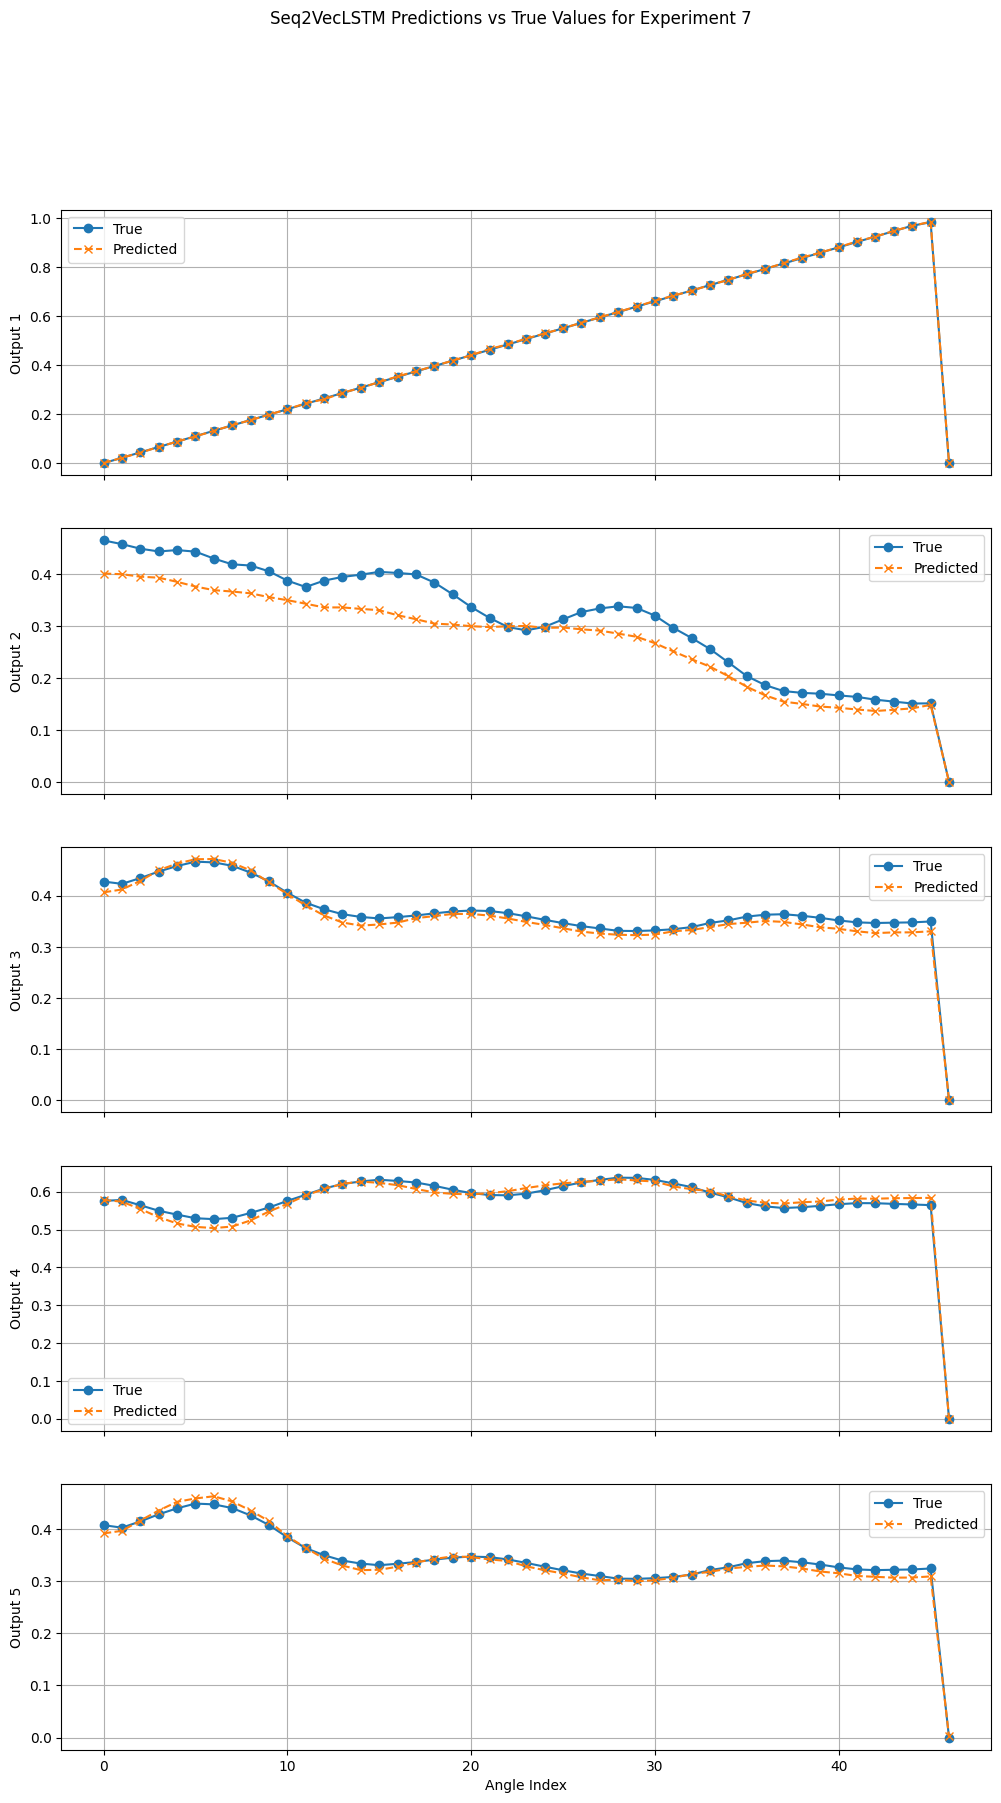

In [22]:
model.eval()
with torch.no_grad():
    Y_pred, attn_weights = model(X_tensor)

# Move to CPU and convert to numpy
Y_pred = Y_pred.detach().cpu().numpy()           # (num_samples, num_angles, num_outputs)
attn_weights = attn_weights.detach().cpu().numpy()  # (num_samples, num_angles, seq_len)

num_outputs = Y_pred.shape[2]
experiment_idx = 7  # select experiment

# True and predicted values for this experiment
true_vals = Y_tensor[experiment_idx].cpu().numpy()  # (num_angles, num_outputs)
pred_vals = Y_pred[experiment_idx]                  # (num_angles, num_outputs)

# -----------------------
# Plot predictions vs true values for all outputs
# -----------------------
fig, axs = plt.subplots(num_outputs, 1, figsize=(12, 4*num_outputs), sharex=True)
axs = np.atleast_1d(axs)

output_names = [f"Output {i+1}" for i in range(num_outputs)]

for i in range(num_outputs):
    axs[i].plot(true_vals[:, i], label="True", marker='o')
    axs[i].plot(pred_vals[:, i], label="Predicted", marker='x', linestyle='--')
    axs[i].set_ylabel(output_names[i])
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel("Angle Index")
plt.suptitle(f"Seq2VecLSTM Predictions vs True Values for Experiment {experiment_idx}")
plt.show()

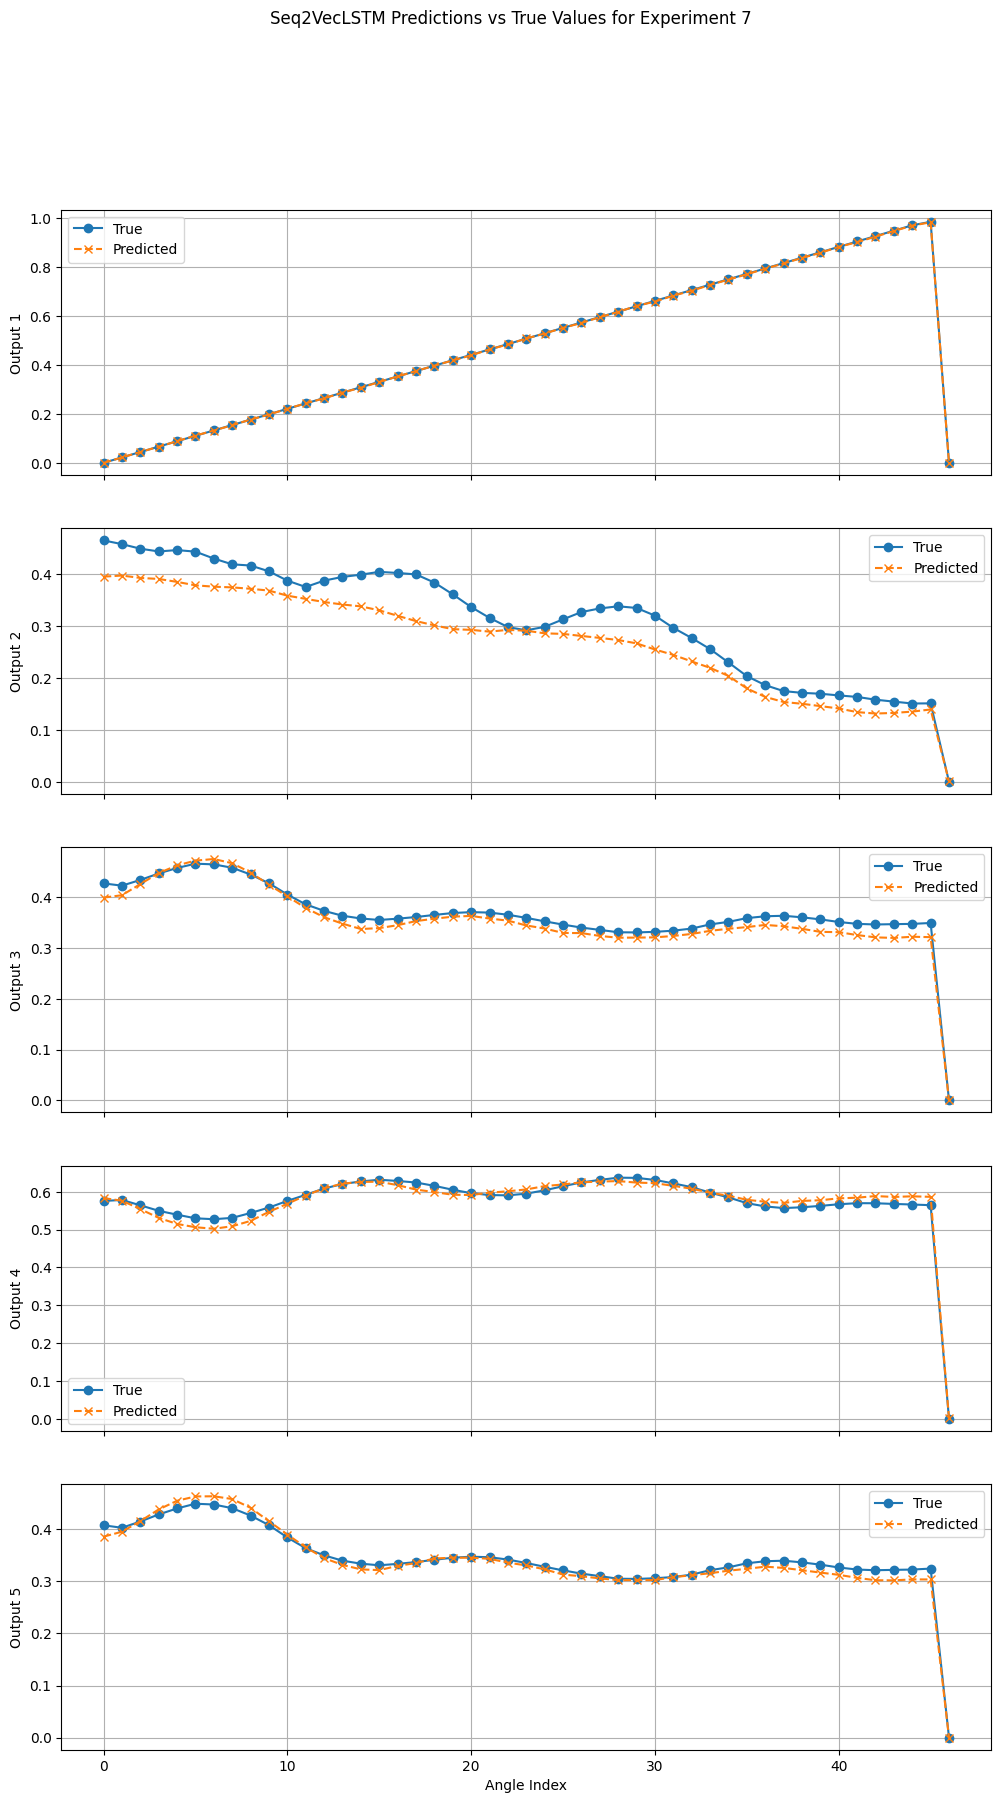

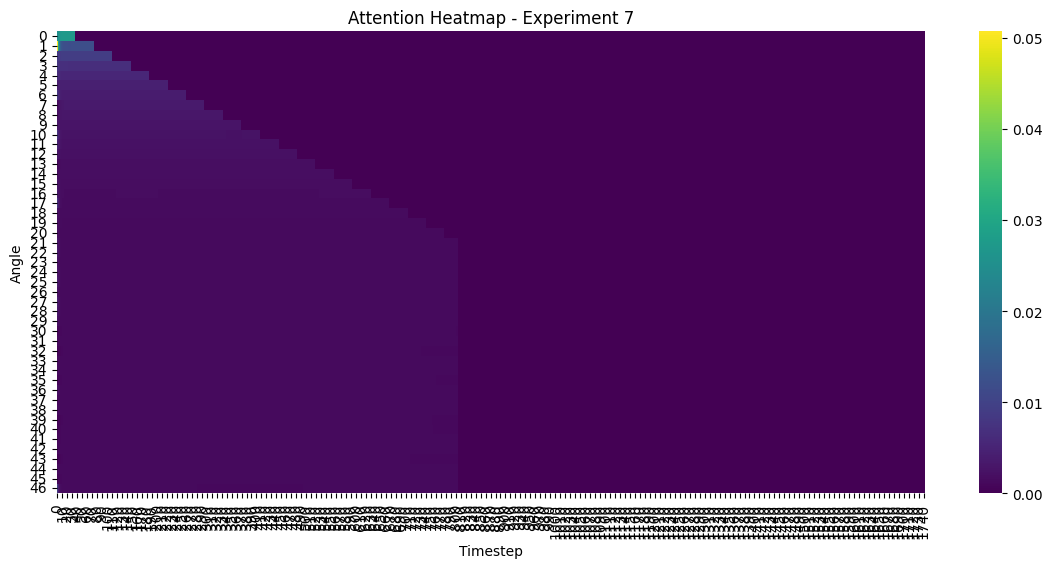

Experiment 7 - MSE: 0.000559, RMSE: 0.023654, MAE: 0.015253


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import torch
import seaborn as sns  # for nice heatmap plotting

# -----------------------
# Make predictions and get attention weights
# -----------------------
model.eval()
with torch.no_grad():
    Y_pred, attn_weights = model(X_tensor)

# Move to CPU and convert to numpy
Y_pred = Y_pred.detach().cpu().numpy()           # (num_samples, num_angles, num_outputs)
attn_weights = attn_weights.detach().cpu().numpy()  # (num_samples, num_angles, seq_len)

num_outputs = Y_pred.shape[2]
experiment_idx = 7  # select experiment

# True and predicted values for this experiment
true_vals = Y_tensor[experiment_idx].cpu().numpy()  # (num_angles, num_outputs)
pred_vals = Y_pred[experiment_idx]                  # (num_angles, num_outputs)

# -----------------------
# Plot predictions vs true values for all outputs
# -----------------------
fig, axs = plt.subplots(num_outputs, 1, figsize=(12, 4*num_outputs), sharex=True)
axs = np.atleast_1d(axs)

output_names = [f"Output {i+1}" for i in range(num_outputs)]

for i in range(num_outputs):
    axs[i].plot(true_vals[:, i], label="True", marker='o')
    axs[i].plot(pred_vals[:, i], label="Predicted", marker='x', linestyle='--')
    axs[i].set_ylabel(output_names[i])
    axs[i].grid(True)
    axs[i].legend()

axs[-1].set_xlabel("Angle Index")
plt.suptitle(f"Seq2VecLSTM Predictions vs True Values for Experiment {experiment_idx}")
plt.show()

# -----------------------
# Attention heatmap
# -----------------------
attn_exp = attn_weights[experiment_idx]  # shape: (num_angles, seq_len)
plt.figure(figsize=(14, 6))
sns.heatmap(attn_exp, cmap='viridis', cbar=True, xticklabels=10, yticklabels=1)
plt.xlabel("Timestep")
plt.ylabel("Angle")
plt.title(f"Attention Heatmap - Experiment {experiment_idx}")
plt.show()

# -----------------------
# Compute evaluation metrics
# -----------------------
mse = mean_squared_error(true_vals, pred_vals)
mae = mean_absolute_error(true_vals, pred_vals)
rmse = np.sqrt(mse)

print(f"Experiment {experiment_idx} - MSE: {mse:.6f}, RMSE: {rmse:.6f}, MAE: {mae:.6f}")
